# 08 – Vertiefung: AWGN-Signal, Rauschspannung und Leistung

Wir erzeugen ein **AWGN-Signal** (Additive White Gaussian Noise) mit vorgegebener **Standardabweichung $\sigma$**, plotten 1000 Abtastwerte und interpretieren das Signal als **Rauschspannung** an einem Widerstand $R = 50\,\Omega$. Daraus ermitteln wir die **durchschnittliche Leistung** und prüfen den Zusammenhang mit der **Varianz** des AWGN-Signals.

**Navigation:** [← 08_Zufallszahlen (Hauptkapitel)](08_Zufallszahlen.ipynb) | [Würfelspiel](08_Zufallszahlen_Wuerfelspiel_Histogramm.ipynb) | AWGN & Leistung

## AWGN-Signal mit Parameter $\sigma$

**AWGN** (Additive White Gaussian Noise): mittelwertfreies Gaußsches Rauschen mit **Varianz $\sigma^2$** und Standardabweichung $\sigma$. In NumPy erzeugen wir es mit **`np.random.normal(0, sigma, N)`** – Mittelwert 0, Standardabweichung `sigma`, $N$ Abtastwerte.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

sigma = 0.5   # Standardabweichung in V (Rauschspannung)
N = 1000      # Anzahl Samples

# AWGN: Mittelwert 0, Standardabweichung sigma
v = np.random.normal(0, sigma, N)

print(f"Standardabweichung σ = {sigma} V")
print(f"Stichproben-Varianz (sollte ≈ σ²): {np.var(v):.6f}")
print(f"Stichproben-Mittelwert (sollte ≈ 0): {np.mean(v):.6f}")

Standardabweichung σ = 0.5 V
Stichproben-Varianz (sollte ≈ σ²): 0.250394
Stichproben-Mittelwert (sollte ≈ 0): -0.019782


## Plot: 1000 Samples des AWGN-Signals

Wir plotten die Rauschspannung $v(t)$ über dem Sample-Index (Zeitachse in Abtastschritten).

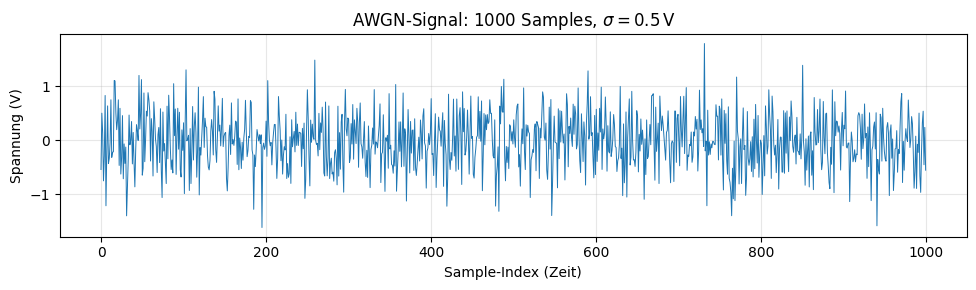

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(v, color="C0", linewidth=0.7)
plt.xlabel("Sample-Index (Zeit)")
plt.ylabel("Spannung (V)")
plt.title(r"AWGN-Signal: 1000 Samples, $\sigma = " + str(sigma) + r"\,\mathrm{V}$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Histogramm der Rauschspannung mit Markern bei $\pm\sigma$

Die **Verteilung** der Rauschspannung lässt sich mit einem Histogramm darstellen. Bei AWGN erwarten wir eine **glockenförmige** (Gauß-)Verteilung um den Mittelwert 0. Die **Standardabweichung $\sigma$** kennzeichnet die typische Abweichung vom Mittelwert. Zur Orientierung zeichnen wir **vertikale gestrichelte Linien** bei $v = -\sigma$ und $v = +\sigma$.

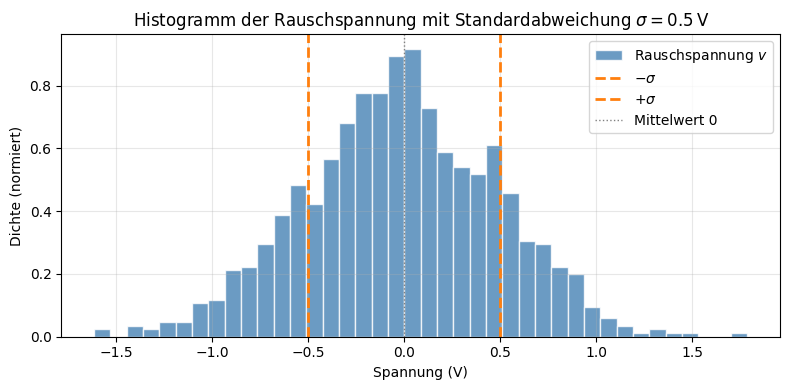

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(v, bins=40, color="steelblue", edgecolor="white", density=True, alpha=0.8, label="Rauschspannung $v$")
plt.axvline(-sigma, color="C1", linestyle="--", linewidth=2, label=r"$-\sigma$")
plt.axvline(sigma, color="C1", linestyle="--", linewidth=2, label=r"$+\sigma$")
plt.axvline(0, color="gray", linestyle=":", linewidth=1, label="Mittelwert 0")
plt.xlabel("Spannung (V)")
plt.ylabel("Dichte (normiert)")
plt.title(r"Histogramm der Rauschspannung mit Standardabweichung $\sigma = " + str(sigma) + r"\,\mathrm{V}$")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rauschspannung an $R = 50\,\Omega$ – durchschnittliche Leistung

Fällt die Spannung $v(t)$ an einem ohmschen Widerstand $R$ ab, ist die **Momentanleistung** $p(t) = v(t)^2 / R$. Die **durchschnittliche Leistung** (über die $N$ Samples) ist
$$ P_{\mathrm{avg}} = \frac{1}{N} \sum_{i=1}^{N} \frac{v_i^2}{R} = \frac{1}{R} \cdot \frac{1}{N}\sum_{i=1}^{N} v_i^2 \,. $$
Der Ausdruck $\frac{1}{N}\sum_i v_i^2$ ist die **empirische Varianz** (wenn der Mittelwert 0 ist). Also: $P_{\mathrm{avg}} \approx \sigma^2 / R$.

In [3]:
R = 50.0   # Widerstand in Ohm

# Momentanleistung pro Sample: p_i = v_i^2 / R
p = v ** 2 / R

# Durchschnittliche Leistung (Mittelwert der Momentanleistung)
P_avg = np.mean(p)

# Alternative: P_avg = (1/R) * mean(v^2) = (1/R) * Var(v) bei Mittelwert 0
varianz = np.var(v)
P_avg_aus_varianz = varianz / R

print(f"Durchschnittliche Leistung (numerisch):  P_avg = {P_avg:.6f} W")
print(f"Aus Varianz:  σ²/R = {sigma**2 / R:.6f} W")
print(f"P_avg aus Var(v)/R:  {P_avg_aus_varianz:.6f} W")
print(f"Varianz des Signals: {varianz:.6f}  (erwartet σ² = {sigma**2:.6f})")

Durchschnittliche Leistung (numerisch):  P_avg = 0.005016 W
Aus Varianz:  σ²/R = 0.005000 W
P_avg aus Var(v)/R:  0.005008 W
Varianz des Signals: 0.250394  (erwartet σ² = 0.250000)


## Zusammenhang: Varianz und Leistung

Für ein **mittelwertfreies** Zufallssignal (wie AWGN mit $\\mu=0$) gilt:
$$ \mathrm{Var}(v) = \mathbb{E}[v^2] - (\mathbb{E}[v])^2 = \mathbb{E}[v^2] \,. $$
Die **durchschnittliche Leistung** an $R$ ist $P_{\mathrm{avg}} = \mathbb{E}[v^2]/R = \sigma^2/R$. Die **Varianz $\sigma^2$** des AWGN-Signals bestimmt also direkt die **mittlere Rauschleistung** am Widerstand.

## Was können wir daraus schlussfolgern?

1. **Leistung ↔ Varianz:** Bei mittelwertfreiem Rauschen an $R$ gilt $P_{\mathrm{avg}} = \sigma^2/R$. Je größer $\sigma$, desto größer die Rauschleistung.

2. **Rauschleistung in der KT:** In der Kommunikationstechnik wird Rauschleistung oft über die **Varianz** (oder $\sigma$) des AWGN-Modells angegeben; die Formel $P = \sigma^2/R$ verbindet Modellparameter mit der physikalisch messbaren Leistung.

3. **Numerische Kontrolle:** Wir können $\sigma$ vorgeben, AWGN erzeugen, $P_{\mathrm{avg}} = \mathrm{mean}(v^2)/R$ berechnen und mit $\sigma^2/R$ vergleichen – bei genügend Samples stimmen die Werte gut überein.

In [4]:
a = 12
b = 13
c=a+b

In [5]:
print(c)

25
